<a href="https://colab.research.google.com/github/Ajaykakade24/PRODIGY_WD_02/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

In [7]:
df = pd.read_csv('/content/IPL_Matches_tail_300.csv')
print(df.shape)
df.head()

(300, 25)


,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,team2_runs,team2_wickets,winner,result_type,win_by_runs,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,20-05-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Chennai Super Kings,Rajasthan Royals,Chennai Super Kings,bat,150.0,6,151.0,5,Rajasthan Royals,complete,0,5,R Ashwin,M Nayyar,CB Gaffaney,NA Patwardhan,YC Barde,PG Pathak,20,"RD Gaikwad, DP Conway, MM Ali, N Jagadeesan, A...","YBK Jaiswal, JC Buttler, SV Samson, D Padikkal..."
1,21-05-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Delhi Capitals,Mumbai Indians,Mumbai Indians,field,159.0,7,160.0,5,Mumbai Indians,complete,0,5,JJ Bumrah,J Srinath,Nitin Menon,Tapan Sharma,HAS Khalid,GR Sadashiv Iyer,20,"PP Shaw, DA Warner, MR Marsh, RR Pant, SN Khan...","Ishan Kishan, RG Sharma, D Brevis, Tilak Varma..."
2,22-05-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,Punjab Kings,Sunrisers Hyderabad,bat,157.0,8,160.0,5,Punjab Kings,complete,0,5,Harpreet Brar,J Srinath,AK Chaudhary,NA Patwardhan,CB Gaffaney,Navdeep Singh,20,"PK Garg, Abhishek Sharma, RA Tripathi, AK Mark...","JM Bairstow, S Dhawan, M Shahrukh Khan, MA Aga..."
3,24-05-2022,2022,Kolkata,"Eden Gardens, Kolkata",Rajasthan Royals,Gujarat Titans,Gujarat Titans,field,188.0,6,191.0,3,Gujarat Titans,complete,0,7,DA Miller,M Nayyar,BNJ Oxenford,VK Sharma,MA Gough,J Madanagopal,20,"YBK Jaiswal, JC Buttler, SV Samson, D Padikkal...","WP Saha, Shubman Gill, MS Wade, HH Pandya, DA ..."
4,25-05-2022,2022,Kolkata,"Eden Gardens, Kolkata",Royal Challengers Bangalore,Lucknow Super Giants,Lucknow Super Giants,field,207.0,4,193.0,6,Royal Challengers Bangalore,complete,14,0,RM Patidar,M Nayyar,J Madanagopal,MA Gough,BNJ Oxenford,VK Sharma,20,"V Kohli, F du Plessis, RM Patidar, GJ Maxwell,...","Q de Kock, KL Rahul, M Vohra, DJ Hooda, MP Sto..."


In [8]:
#missing value summary
df.tail().isnull().sum().sort_values(ascending=False)

,0
team1_runs,1
winner,1
player_of_match,1
team2_runs,1
date,0
team1,0
season,0
venue,0
city,0
toss_decision,0


In [10]:
#mean imputation (team1_runs)
mean_df = df.copy()
mean_value = mean_df['team1_runs'].mean()
print('Mean:', mean_value)

Mean: 188.13651877133105


In [13]:
median_df = df.copy()
median_value = median_df['team2_runs'].median()
print('median:',median_value)

median: 175.0


In [14]:
mean_df['team1_runs'] = mean_df['team1_runs'].fillna(mean_value)
mean_df['team1_runs'].isnull().sum()

np.int64(0)

In [15]:
mean_df['team2_runs'] = mean_df['team2_runs'].fillna(mean_value)
mean_df['team2_runs'].isnull().sum()

np.int64(0)

In [16]:
#mode imputation (winner and player of match)
mode_df = df.copy()
mode_df['winner'] = mode_df['winner'].fillna(mode_df['winner'].mode()[0])
mode_df['player_of_match'] = mode_df['player_of_match'] = mode_df['player_of_match'].fillna(mode_df['player_of_match'])
mode_df[['winner','player_of_match']].isnull().sum()

,0
winner,0
player_of_match,10


In [18]:
#using simpleImputer
mean_Imp = SimpleImputer(str = 'mean')
median_Imp = SimpleImputer(str = 'medianan')
mode_Imp = SimpleImputer(str = 'most_frequent')

df['team1_runs'] = mean_Imp.fit_transform(df[['team1_runs']])
df['team2_runs'] = median_Imp.fit_transform(df[['team2_runs']])
df[['winner']] = mode_Imp.fit_transform(df[['winner']])
df[['player_of_match']] = mode_Imp.fit_transform(df[['player_of_match']])
df.isnull().sum().sum()

TypeError: SimpleImputer.__init__() got an unexpected keyword argument 'str'

In [19]:
from sklearn.impute import SimpleImputer

# Using SimpleImputer
mean_Imp = SimpleImputer(strategy='mean')
median_Imp = SimpleImputer(strategy='median')
mode_Imp = SimpleImputer(strategy='most_frequent')

df['team1_runs'] = mean_Imp.fit_transform(df[['team1_runs']])

df['team2_runs'] = median_Imp.fit_transform(df[['team2_runs']])

df[['winner']] = mode_Imp.fit_transform(df[['winner']])

df[['player_of_match']] = mode_Imp.fit_transform(df[['player_of_match']])

print(df.isnull().sum())

date               0
season             0
city               0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
team1_runs         0
team1_wickets      0
team2_runs         0
team2_wickets      0
winner             0
result_type        0
win_by_runs        0
win_by_wickets     0
player_of_match    0
match_referee      0
umpire1            0
umpire2            0
tv_umpire          0
reserve_umpire     0
overs_limit        0
team1_players      0
team2_players      0
dtype: int64


venue
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh    425.857143
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam         387.250000
Arun Jaitley Stadium, Delhi                                                374.351405
Himachal Pradesh Cricket Association Stadium, Dharamsala                   374.000000
Wankhede Stadium, Mumbai                                                   372.933333
Sawai Mansingh Stadium, Jaipur                                             372.673168
M Chinnaswamy Stadium, Bengaluru                                           371.422355
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh           371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                       368.818194
Eden Gardens, Kolkata                                                      361.204551
Name: total_runs, dtype: float64


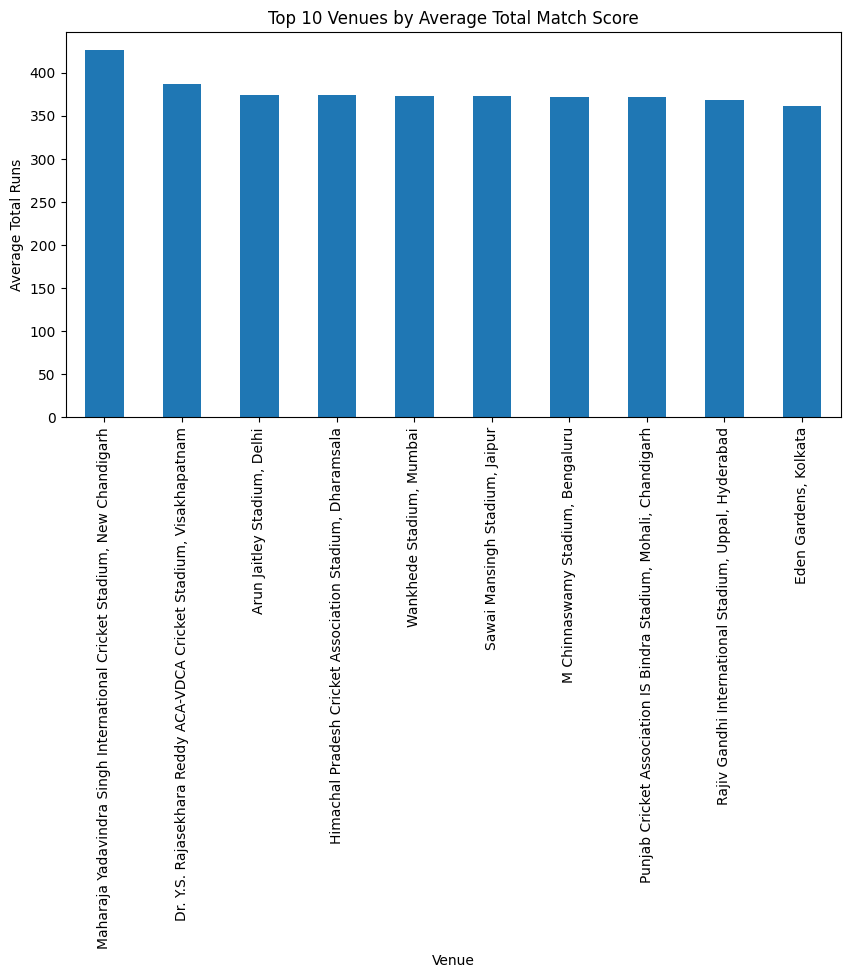

In [21]:
#1.#analyze  which stadiums have the highest average total match score team1 and team2 runs rank the top venues and visualize the results
import matplotlib.pyplot as plt

# Create total runs column
df['total_runs'] = df['team1_runs'] + df['team2_runs']

# Average total runs by venue
avg_runs = df.groupby('venue')['total_runs'].mean().sort_values(ascending=False).head(10)

print(avg_runs)

# Plot
plt.figure(figsize=(10,5))
avg_runs.plot(kind='bar')
plt.title("Top 10 Venues by Average Total Match Score")
plt.xlabel("Venue")
plt.ylabel("Average Total Runs")
plt.xticks(rotation=90)
plt.show()


Bat First Win % : 40.0
Field First Win % : 51.30434782608696


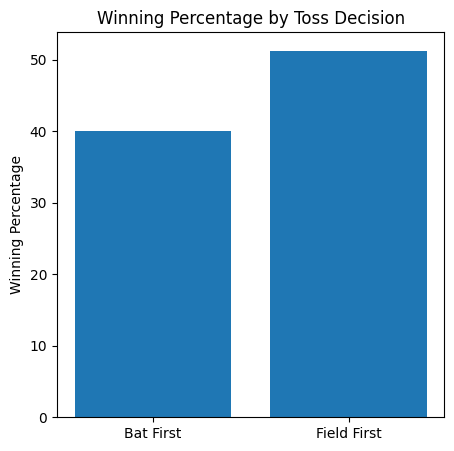

In [22]:
#2. Determine whether teams that choose to bat first or field first after winning the toss have a better winning percentage
# Toss winner won the match?
df['toss_win_match'] = df['toss_winner'] == df['winner']

# Bat First
bat = df[df['toss_decision'] == 'bat']

# Field First
field = df[df['toss_decision'] == 'field']

bat_win = (bat['toss_win_match'].sum() / len(bat)) * 100
field_win = (field['toss_win_match'].sum() / len(field)) * 100

print("Bat First Win % :", bat_win)
print("Field First Win % :", field_win)

plt.figure(figsize=(5,5))
plt.bar(['Bat First','Field First'], [bat_win, field_win])
plt.ylabel("Winning Percentage")
plt.title("Winning Percentage by Toss Decision")
plt.show()

season
2022    164.000000
2023    182.569412
2024    190.017930
2025    189.517203
2026    192.800987
Name: team1_runs, dtype: float64


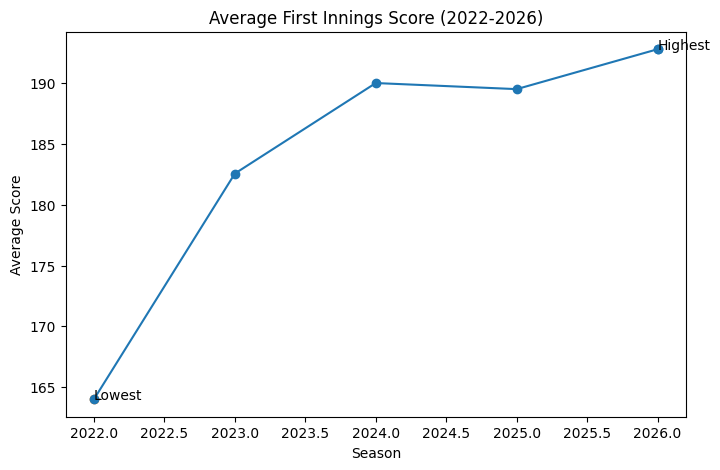

In [23]:
#.Analyze the average 1st innings score has changed from season to season and identify season with  unually high or low  scoring trends

season_df = df[df['season'].between(2022, 2026)]

avg_score = season_df.groupby('season')['team1_runs'].mean()

print(avg_score)

highest = avg_score.idxmax()
lowest = avg_score.idxmin()

plt.figure(figsize=(8,5))
plt.plot(avg_score.index, avg_score.values, marker='o')

plt.scatter(highest, avg_score.max())
plt.scatter(lowest, avg_score.min())

plt.annotate("Highest", (highest, avg_score.max()))
plt.annotate("Lowest", (lowest, avg_score.min()))

plt.title("Average First Innings Score (2022-2026)")
plt.xlabel("Season")
plt.ylabel("Average Score")

plt.show()

Top 10 Stadiums by Average Total Score
venue
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh    425.857143
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam         387.250000
Arun Jaitley Stadium, Delhi                                                374.800000
Himachal Pradesh Cricket Association Stadium, Dharamsala                   374.000000
Sawai Mansingh Stadium, Jaipur                                             373.150000
Wankhede Stadium, Mumbai                                                   372.933333
M Chinnaswamy Stadium, Bengaluru                                           371.782609
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh           371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                       369.291667
Eden Gardens, Kolkata                                                      361.137931
Name: total_runs, dtype: float64


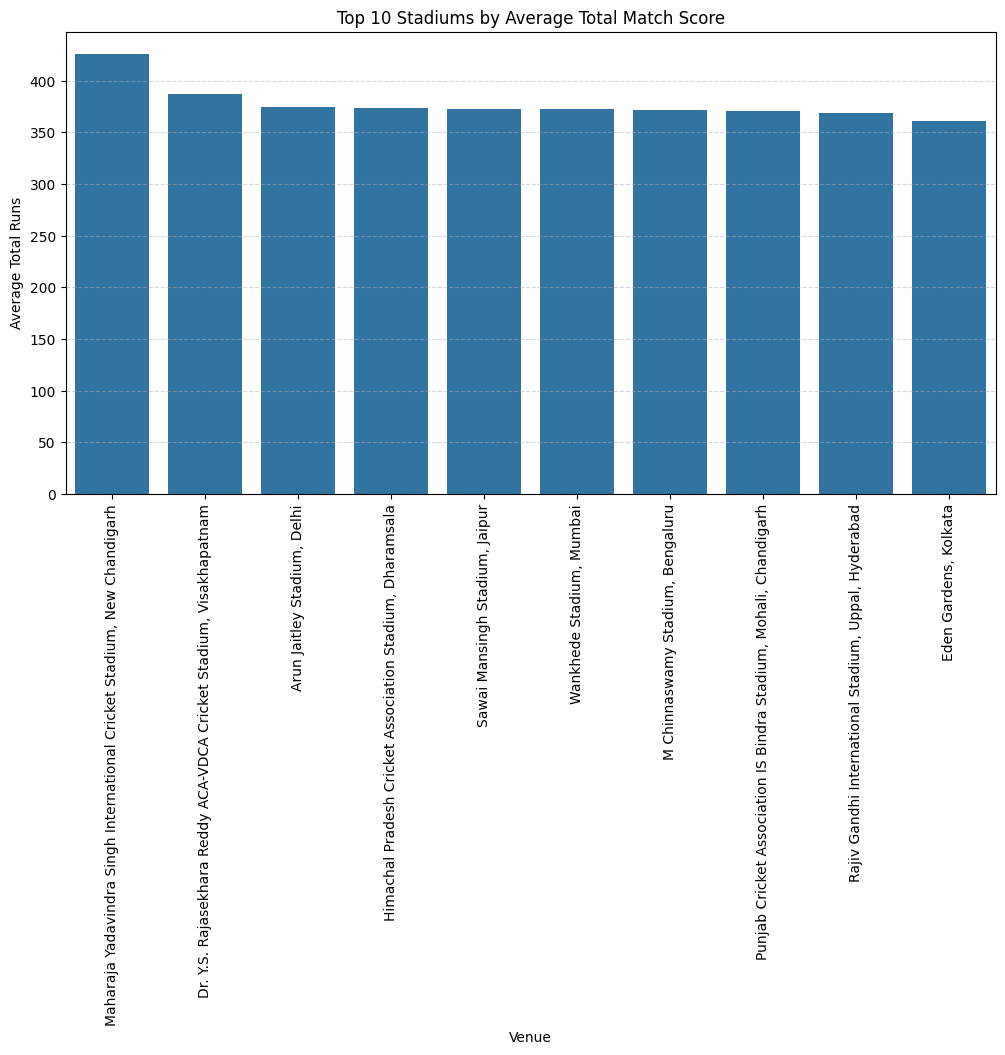

In [26]:
#.create a dashboard  for each ipl team showing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/IPL_Matches_tail_300.csv")

# Create total_runs column
df["total_runs"] = df["team1_runs"] + df["team2_runs"]

# Calculate average total runs by venue
top10 = (df.groupby("venue")["total_runs"]
           .mean()
           .sort_values(ascending=False)
           .head(10))

print("Top 10 Stadiums by Average Total Score")
print(top10)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x=top10.index, y=top10.values)

plt.title("Top 10 Stadiums by Average Total Match Score")
plt.xlabel("Venue")
plt.ylabel("Average Total Runs")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



Home vs Overall Performance

                           Team  ... Home Advantage
5                Mumbai Indians  ...          10.91
0           Chennai Super Kings  ...           9.50
10          Sunrisers Hyderabad  ...           5.00
2                Gujarat Titans  ...          -0.67
9   Royal Challengers Bengaluru  ...          -2.05
4          Lucknow Super Giants  ...          -3.81
3         Kolkata Knight Riders  ...          -6.23
8   Royal Challengers Bangalore  ...          -7.14
7              Rajasthan Royals  ...          -9.19
1                Delhi Capitals  ...          -9.77
6                  Punjab Kings  ...         -17.54

[11 rows x 7 columns]


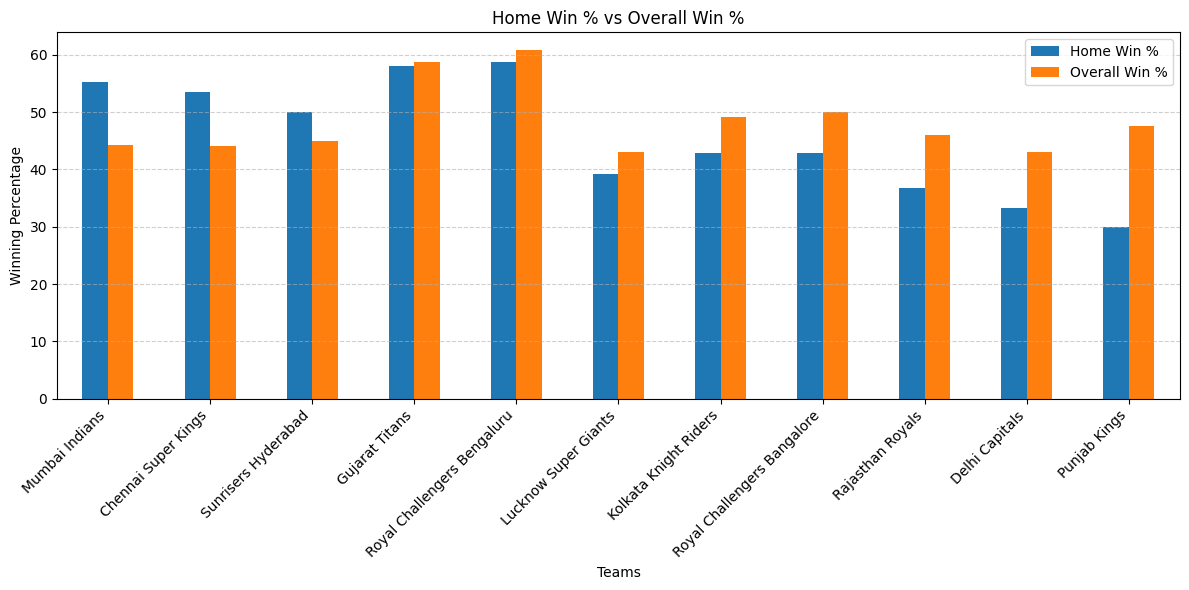

In [27]:
#5.investigate whether teams perform better  at their frequently used home venues.compare their home win percentage withtheir  overall win percentage and summarize your finding
home_venues = (
    df.groupby("team1")["venue"]
      .agg(lambda x: x.value_counts().idxmax())
)

home_stats = []

for team, venue in home_venues.items():

    home_matches = df[
        ((df["team1"] == team) | (df["team2"] == team)) &
        (df["venue"] == venue)
    ]

    total_home_matches = len(home_matches)

    home_wins = len(home_matches[home_matches["winner"] == team])

    if total_home_matches > 0:
        home_win_percentage = (home_wins / total_home_matches) * 100
    else:
        home_win_percentage = 0

    home_stats.append([team, venue, total_home_matches,
                       home_wins, round(home_win_percentage, 2)])

home_df = pd.DataFrame(home_stats, columns=[
    "Team",
    "Home Venue",
    "Home Matches",
    "Home Wins",
    "Home Win %"
])

matches_played = pd.concat([df["team1"], df["team2"]]).value_counts()

wins = df["winner"].value_counts()

overall_df = pd.DataFrame({
    "Matches Played": matches_played,
    "Wins": wins
}).fillna(0)

overall_df["Overall Win %"] = (
    overall_df["Wins"] /
    overall_df["Matches Played"] * 100
).round(2)

overall_df = overall_df.reset_index()
overall_df.columns = ["Team", "Matches Played", "Wins", "Overall Win %"]

comparison = pd.merge(
    home_df,
    overall_df[["Team", "Overall Win %"]],
    on="Team"
)

comparison["Home Advantage"] = (
    comparison["Home Win %"] -
    comparison["Overall Win %"]
).round(2)

comparison = comparison.sort_values(
    by="Home Advantage",
    ascending=False
)

print("\nHome vs Overall Performance\n")
print(comparison)

comparison.set_index("Team")[["Home Win %", "Overall Win %"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Home Win % vs Overall Win %")
plt.xlabel("Teams")
plt.ylabel("Winning Percentage")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


Home vs Overall Performance

                           Team  ... Home Advantage
5                Mumbai Indians  ...          10.91
0           Chennai Super Kings  ...           9.50
10          Sunrisers Hyderabad  ...           5.00
2                Gujarat Titans  ...          -0.67
9   Royal Challengers Bengaluru  ...          -2.05
4          Lucknow Super Giants  ...          -3.81
3         Kolkata Knight Riders  ...          -6.23
8   Royal Challengers Bangalore  ...          -7.14
7              Rajasthan Royals  ...          -9.19
1                Delhi Capitals  ...          -9.77
6                  Punjab Kings  ...         -17.54

[11 rows x 7 columns]


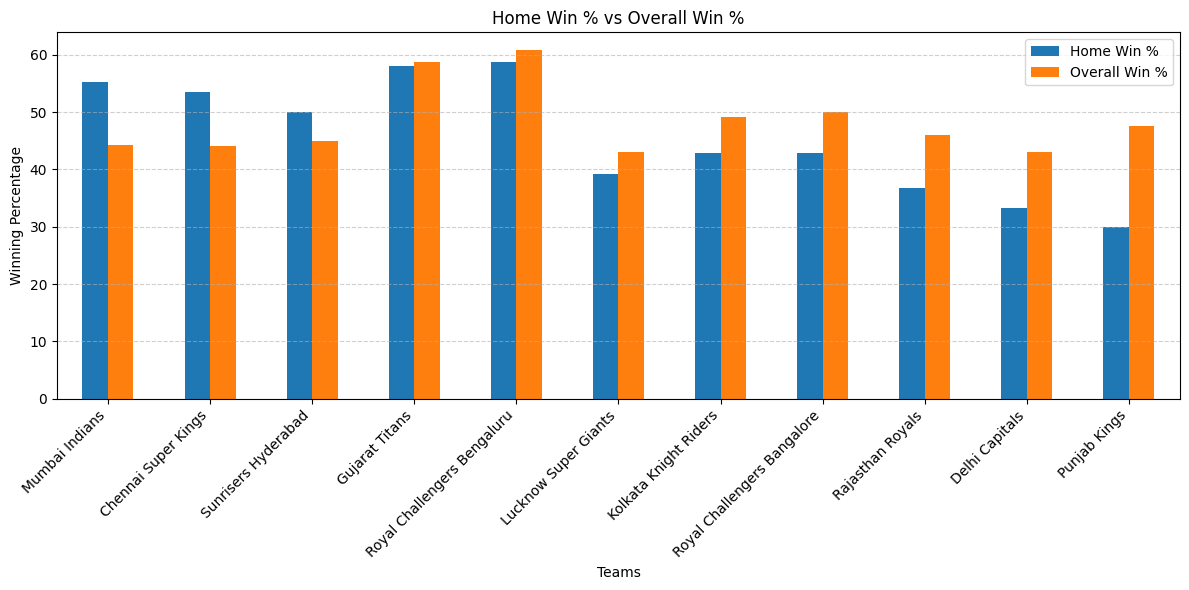

In [29]:
#'''Question 6: For every column containing missing values, determine whether Mean, Median, or Mode is the most suitable imputation technique.
#Justify your choice based on the column's data type and distribution.'''
home_venues = (
    df.groupby("team1")["venue"]
      .agg(lambda x: x.value_counts().idxmax())
)

home_stats = []

for team, venue in home_venues.items():

    home_matches = df[
        ((df["team1"] == team) | (df["team2"] == team)) &
        (df["venue"] == venue)
    ]

    total_home_matches = len(home_matches)

    home_wins = len(home_matches[home_matches["winner"] == team])

    if total_home_matches > 0:
        home_win_percentage = (home_wins / total_home_matches) * 100
    else:
        home_win_percentage = 0

    home_stats.append([team, venue, total_home_matches,
                       home_wins, round(home_win_percentage, 2)])

home_df = pd.DataFrame(home_stats, columns=[
    "Team",
    "Home Venue",
    "Home Matches",
    "Home Wins",
    "Home Win %"
])

matches_played = pd.concat([df["team1"], df["team2"]]).value_counts()

wins = df["winner"].value_counts()

overall_df = pd.DataFrame({
    "Matches Played": matches_played,
    "Wins": wins
}).fillna(0)

overall_df["Overall Win %"] = (
    overall_df["Wins"] /
    overall_df["Matches Played"] * 100
).round(2)

overall_df = overall_df.reset_index()
overall_df.columns = ["Team", "Matches Played", "Wins", "Overall Win %"]

comparison = pd.merge(
    home_df,
    overall_df[["Team", "Overall Win %"]],
    on="Team"
)

comparison["Home Advantage"] = (
    comparison["Home Win %"] -
    comparison["Overall Win %"]
).round(2)

comparison = comparison.sort_values(
    by="Home Advantage",
    ascending=False
)

print("\nHome vs Overall Performance\n")
print(comparison)

comparison.set_index("Team")[["Home Win %", "Overall Win %"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Home Win % vs Overall Win %")
plt.xlabel("Teams")
plt.ylabel("Winning Percentage")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Before Adding Outliers
Mean   : 188.14
Median : 191.0

After Adding Outliers
Mean   : 193.12
Median : 192.0

Comparison Table
  Statistic  Before Outliers  After Outliers
0      Mean       188.136519      193.116041
1    Median       191.000000      192.000000


/tmp/ipykernel_5931/3943108315.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


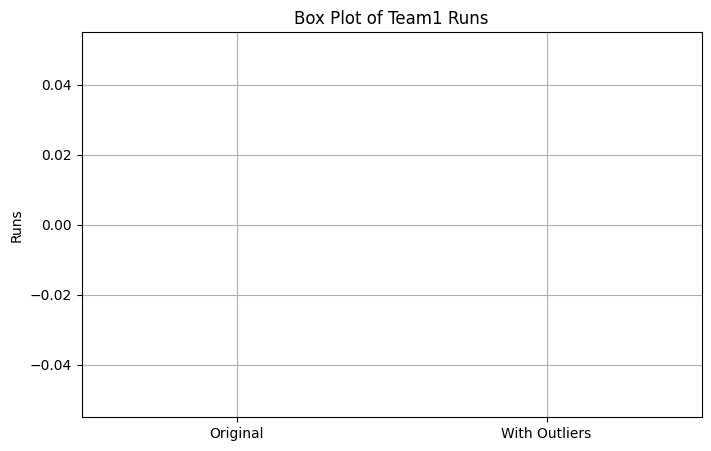

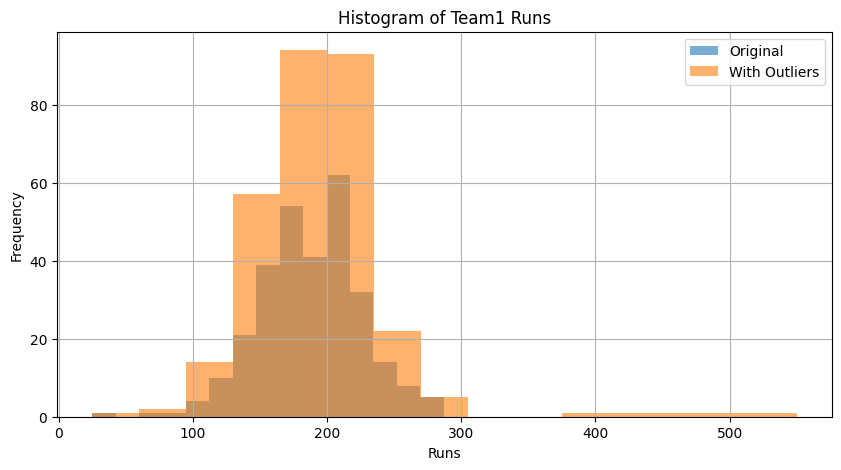

In [35]:
'''Question 7: Introduce a few extreme run values into the team1_runs column.
Compare the Mean and Median before and after adding outliers, and explain which imputation'''

df_outlier = df.copy()

mean_before = df["team1_runs"].mean()
median_before = df["team1_runs"].median()

print("Before Adding Outliers")
print("Mean   :", round(mean_before, 2))
print("Median :", round(median_before, 2))

df_outlier.loc[df_outlier.index[:5], "team1_runs"] = [400, 420, 450, 500, 550]

mean_after = df_outlier["team1_runs"].mean()
median_after = df_outlier["team1_runs"].median()

print("\nAfter Adding Outliers")
print("Mean   :", round(mean_after, 2))
print("Median :", round(median_after, 2))

comparison = pd.DataFrame({
    "Statistic": ["Mean", "Median"],
    "Before Outliers": [mean_before, median_before],
    "After Outliers": [mean_after, median_after]
})

print("\nComparison Table")
print(comparison)

plt.figure(figsize=(8,5))
plt.boxplot(
    [df["team1_runs"], df_outlier["team1_runs"]],
    labels=["Original", "With Outliers"]
)
plt.title("Box Plot of Team1 Runs")
plt.ylabel("Runs")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))

plt.hist(df["team1_runs"], bins=15, alpha=0.6, label="Original")
plt.hist(df_outlier["team1_runs"], bins=15, alpha=0.6, label="With Outliers")

plt.title("Histogram of Team1 Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

Missing Values Introduced: 51

Comparison Table
                      Original  Mean Imputation  Median Imputation
Mean                188.136519       188.441767         188.706667
Median              191.000000       188.441767         190.000000
Standard Deviation   37.459500        33.785642          33.790729


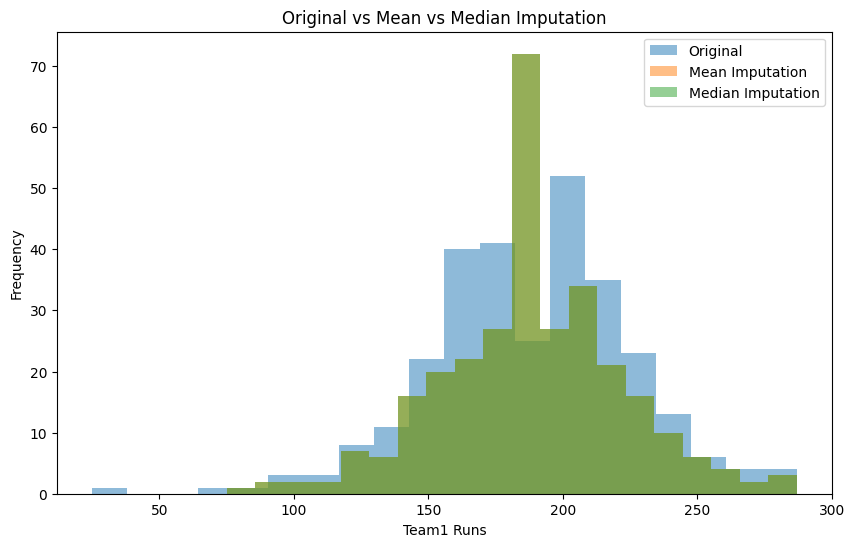

/tmp/ipykernel_5931/2532911536.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


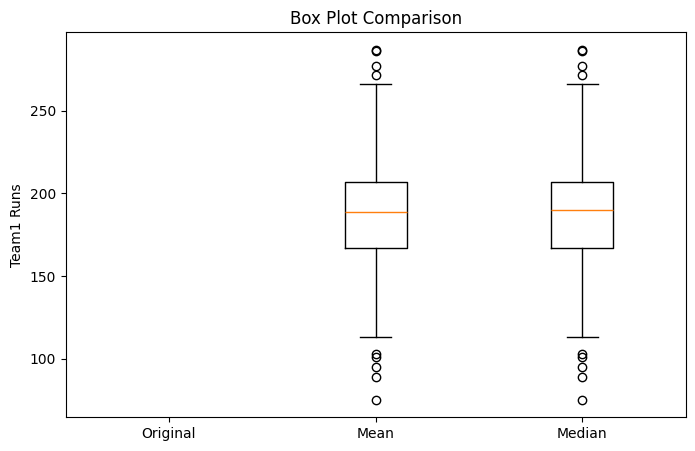

In [36]:
'''Question 8: Randomly remove 15% of the values from a complete numerical column.
Apply Mean and Median imputation separately and compare how closely each restored dataset matches the original.'''

column = "team1_runs"

original = df[column].copy()

df_missing = df.copy()

np.random.seed(42)
missing_index = df_missing.sample(frac=0.15).index

df_missing.loc[missing_index, column] = np.nan

print("Missing Values Introduced:", df_missing[column].isnull().sum())

mean_df = df_missing.copy()
mean_df[column] = mean_df[column].fillna(mean_df[column].mean())

median_df = df_missing.copy()
median_df[column] = median_df[column].fillna(median_df[column].median())

comparison = pd.DataFrame({
    "Original": [
        original.mean(),
        original.median(),
        original.std()
    ],
    "Mean Imputation": [
        mean_df[column].mean(),
        mean_df[column].median(),
        mean_df[column].std()
    ],
    "Median Imputation": [
        median_df[column].mean(),
        median_df[column].median(),
        median_df[column].std()
    ]
},
index=["Mean", "Median", "Standard Deviation"])

print("\nComparison Table")
print(comparison)

plt.figure(figsize=(10,6))

plt.hist(original, bins=20, alpha=0.5, label="Original")
plt.hist(mean_df[column], bins=20, alpha=0.5, label="Mean Imputation")
plt.hist(median_df[column], bins=20, alpha=0.5, label="Median Imputation")

plt.title("Original vs Mean vs Median Imputation")
plt.xlabel("Team1 Runs")
plt.ylabel("Frequency")
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.boxplot([
    original,
    mean_df[column],
    median_df[column]
],
labels=["Original", "Mean", "Median"])

plt.title("Box Plot Comparison")
plt.ylabel("Team1 Runs")

plt.show()

Comparison Table
  Statistic    Original  Mean Imputation  Median Imputation  Mode Imputation
0      Mean  188.136519       188.136519         188.203333       187.456667
1    Median  191.000000       189.500000         191.000000       189.500000
2   Std Dev   37.459500        37.018414          37.020947        37.279673
3   Minimum   25.000000        25.000000          25.000000        25.000000
4   Maximum  287.000000       287.000000         287.000000       287.000000


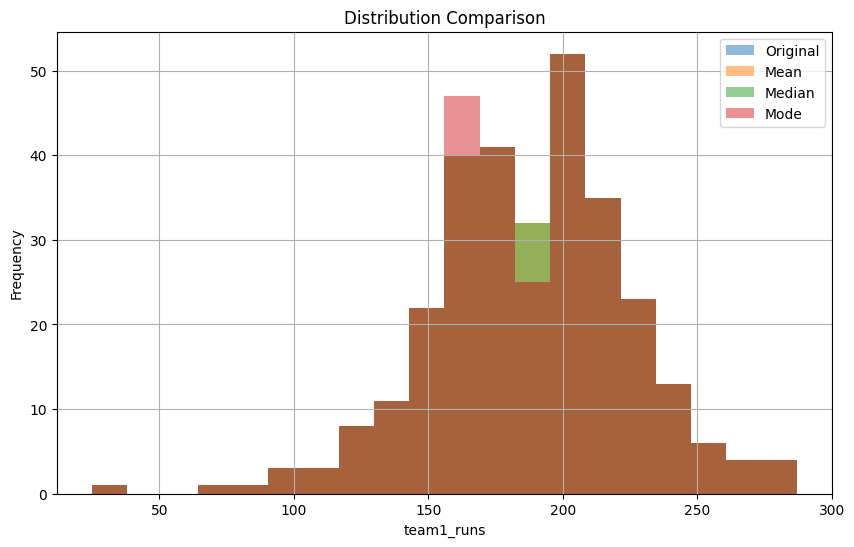

/tmp/ipykernel_5931/793576987.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


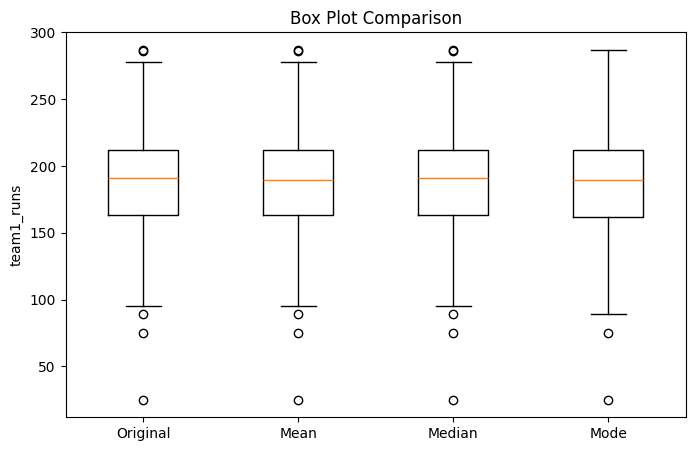

In [37]:
'''Question 9: After applying different imputation techniques, compare the statistical properties of the dataset (Mean, Median, Standard Deviation, Minimum, and Maximum).
  Discuss which technique preserves the original distribution more effectively.'''
mean_df = df.copy()
median_df = df.copy()
mode_df = df.copy()

num_cols = mean_df.select_dtypes(include=['number']).columns

for col in num_cols:
    mean_df[col] = mean_df[col].fillna(mean_df[col].mean())

for col in num_cols:
    median_df[col] = median_df[col].fillna(median_df[col].median())

for col in mode_df.columns:
    mode_df[col] = mode_df[col].fillna(mode_df[col].mode()[0])

column = "team1_runs"

comparison = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Std Dev", "Minimum", "Maximum"],

    "Original": [
        df[column].mean(),
        df[column].median(),
        df[column].std(),
        df[column].min(),
        df[column].max()
    ],

    "Mean Imputation": [
        mean_df[column].mean(),
        mean_df[column].median(),
        mean_df[column].std(),
        mean_df[column].min(),
        mean_df[column].max()
    ],

    "Median Imputation": [
        median_df[column].mean(),
        median_df[column].median(),
        median_df[column].std(),
        median_df[column].min(),
        median_df[column].max()
    ],

    "Mode Imputation": [
        mode_df[column].mean(),
        mode_df[column].median(),
        mode_df[column].std(),
        mode_df[column].min(),
        mode_df[column].max()
    ]
})

print("Comparison Table")
print(comparison)

plt.figure(figsize=(10,6))

plt.hist(df[column].dropna(), bins=20, alpha=0.5, label="Original")
plt.hist(mean_df[column], bins=20, alpha=0.5, label="Mean")
plt.hist(median_df[column], bins=20, alpha=0.5, label="Median")
plt.hist(mode_df[column], bins=20, alpha=0.5, label="Mode")

plt.title("Distribution Comparison")
plt.xlabel(column)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(8,5))

plt.boxplot([
    df[column].dropna(),
    mean_df[column],
    median_df[column],
    mode_df[column]
],
labels=["Original", "Mean", "Median", "Mode"])

plt.title("Box Plot Comparison")
plt.ylabel(column)

plt.show()


Summary Statistics
                      Original  Mean Imputation  Median Imputation
Mean                188.136519       188.136519         188.203333
Median              191.000000       189.500000         191.000000
Standard Deviation   37.459500        37.018414          37.020947


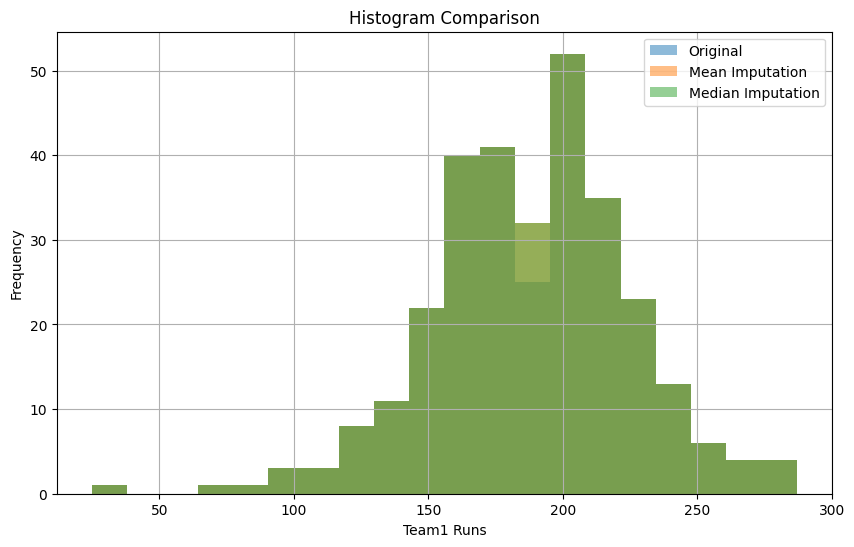

/tmp/ipykernel_5931/3826285067.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


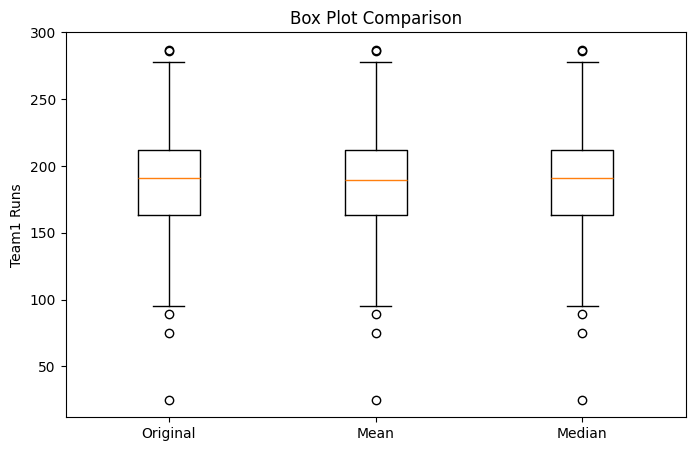

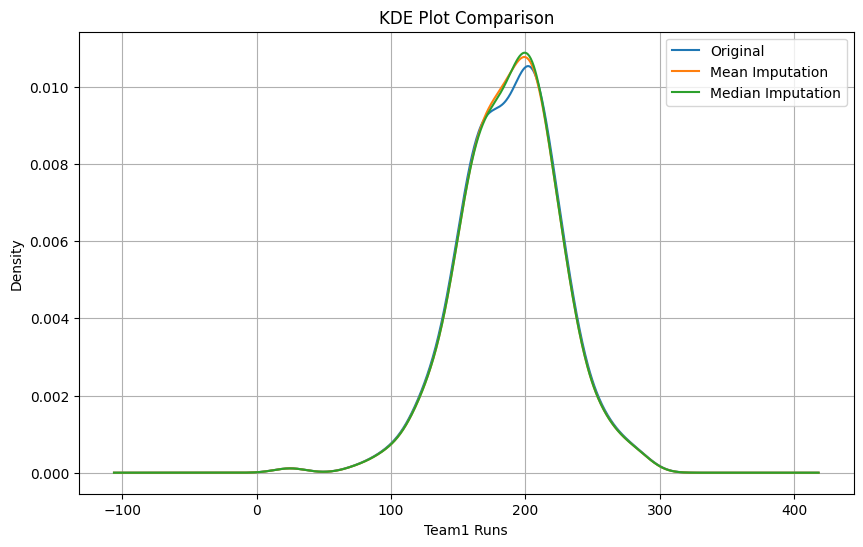

In [38]:
'''Question 10: Create visualizations (Histogram, Box Plot, and KDE Plot) of the team1_runs column before and after applying Mean and Median imputation.
#Compare the distributions and explain which technique better preserves the original data distribution.'''

original = df.copy()

mean_df = df.copy()
mean_df["team1_runs"] = mean_df["team1_runs"].fillna(
    mean_df["team1_runs"].mean()
)

median_df = df.copy()
median_df["team1_runs"] = median_df["team1_runs"].fillna(
    median_df["team1_runs"].median()
)

summary = pd.DataFrame({
    "Original": [
        original["team1_runs"].mean(),
        original["team1_runs"].median(),
        original["team1_runs"].std()
    ],
    "Mean Imputation": [
        mean_df["team1_runs"].mean(),
        mean_df["team1_runs"].median(),
        mean_df["team1_runs"].std()
    ],
    "Median Imputation": [
        median_df["team1_runs"].mean(),
        median_df["team1_runs"].median(),
        median_df["team1_runs"].std()
    ]
},
index=["Mean", "Median", "Standard Deviation"])

print("\nSummary Statistics")
print(summary)

plt.figure(figsize=(10,6))

plt.hist(original["team1_runs"].dropna(),
         bins=20,
         alpha=0.5,
         label="Original")

plt.hist(mean_df["team1_runs"],
         bins=20,
         alpha=0.5,
         label="Mean Imputation")

plt.hist(median_df["team1_runs"],
         bins=20,
         alpha=0.5,
         label="Median Imputation")

plt.title("Histogram Comparison")
plt.xlabel("Team1 Runs")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.boxplot([
    original["team1_runs"].dropna(),
    mean_df["team1_runs"],
    median_df["team1_runs"]
],
labels=["Original", "Mean", "Median"])

plt.title("Box Plot Comparison")
plt.ylabel("Team1 Runs")

plt.show()

plt.figure(figsize=(10,6))

original["team1_runs"].dropna().plot(kind="kde", label="Original")
mean_df["team1_runs"].plot(kind="kde", label="Mean Imputation")
median_df["team1_runs"].plot(kind="kde", label="Median Imputation")

plt.title("KDE Plot Comparison")
plt.xlabel("Team1 Runs")
plt.legend()
plt.grid(True)

plt.show()